# 04 · 1D Convolutional Neural Network — Baseline (unoptimized)
**ICT-4442 HAR comparison · Model 2 of 4 · Owner: Akshaj Vinod Chandak**

Trains a 1D CNN on the raw 9-channel, 128-step inertial windows produced by `01_HAR_Preprocessing.ipynb` — learning local motion patterns directly from the signals, with no hand-crafted features (synopsis, model 2) — then:
- evaluates it with the **shared** `har_common` metrics (identical to the MLP, LSTM and Transformer runs),
- measures efficiency (parameters, size, FLOPs, CPU/GPU latency, training time),
- exports **runnable model files** (TorchScript + ONNX, with clipping/normalization built in) and a `predict.py` script,
- appends its row to the team's `results/comparison_table.csv`.

**Before running:** `01_HAR_Preprocessing.ipynb` must have been run once (in the same Google account). Set **Runtime → Change runtime type → T4 GPU**.

This notebook is a deliberate **parallel of `02_Transformer_Baseline.ipynb`**: same data, same training loop (AdamW, lr 1e-3, batch 64, up to 150 epochs, early-stopping patience 20 on validation macro-F1), same evaluation and export. Only the architecture differs, so differences in results come from the model family. "Baseline" = no augmentation, no class weights, no LR schedule; tuning comes later as `run_tag="tuned"`.

## 0 · Setup

In [2]:
!pip -q install onnx onnxruntime

import os, sys, json, time, copy, glob, subprocess
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

PROJECT_DIR = os.environ.get("HAR_PROJECT_DIR", "/content/drive/MyDrive/HAR")
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

if not os.path.isfile(os.path.join(PROJECT_DIR, "processed", "har_common.py")):
    # Not at the default path: search the mounted Drive for the shared processed folder
    hits = glob.glob("/content/drive/MyDrive/**/processed/har_common.py", recursive=True)
    if not hits:
        raise FileNotFoundError(
            f"processed/har_common.py not found under {PROJECT_DIR} or anywhere in this Drive. "
            "Check that Colab is signed into the same Google account that ran 01_HAR_Preprocessing.ipynb "
            "(if 'DL Proj' is shared with you: Drive -> right-click -> Organize -> Add shortcut -> My Drive).")
    PROJECT_DIR = os.path.dirname(os.path.dirname(sorted(hits, key=lambda h: ("DL Proj" not in h, len(h)))[0]))
print("Project folder:", PROJECT_DIR)
PROC_DIR = os.path.join(PROJECT_DIR, "processed")
sys.path.insert(0, PROC_DIR)
import har_common as hc

MODEL_NAME, FAMILY, OWNER, RUN_TAG = "cnn", "CNN", "Akshaj Vinod Chandak", "baseline"
MODEL_DIR = os.path.join(PROJECT_DIR, "models", MODEL_NAME, RUN_TAG)
os.makedirs(MODEL_DIR, exist_ok=True)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print(f"Device: {DEVICE} {torch.cuda.get_device_name(0) if USE_AMP else ''} | torch {torch.__version__}")
print(f"Dataset version: {hc.DATASET_VERSION} | classes: {hc.CLASSES}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 15.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
Mounted at /content/drive
Project folder: /content/drive/MyDrive/HAR
Device: cuda Tesla T4 | torch 2.11.0+cu130
Dataset version: uci-har-65a1fc6120e8 | classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DO

## 1 · Hyperparameters (baseline defaults — deliberately untuned)

In [3]:
HP = dict(
    channels=(64, 64, 128, 128, 128), kernel_sizes=(5, 5, 5, 5, 3),   # architecture
    pool_after=(1, 3), dropout=0.5, batchnorm=True, pooling="global_avg",
    batch_size=64, lr=1e-3, weight_decay=1e-2, optimizer="AdamW",
    epochs=150, early_stopping_patience=20, grad_clip=1.0,
    augmentation=False, class_weights=False, lr_schedule=None,
)
HP

{'channels': (64, 64, 128, 128, 128),
 'kernel_sizes': (5, 5, 5, 5, 3),
 'pool_after': (1, 3),
 'dropout': 0.5,
 'batchnorm': True,
 'pooling': 'global_avg',
 'batch_size': 64,
 'lr': 0.001,
 'weight_decay': 0.01,
 'optimizer': 'AdamW',
 'epochs': 150,
 'early_stopping_patience': 20,
 'grad_clip': 1.0,
 'augmentation': False,
 'class_weights': False,
 'lr_schedule': None}

## 2 · Load the shared preprocessed data

In [4]:
data = hc.load_data("sequence", augmented_train=HP["augmentation"])
for sp in ("train", "val", "test"):
    print(f"{sp:5s} X {data[f'X_{sp}'].shape}  y {np.bincount(data[f'y_{sp}'], minlength=6)}")

SEQ_LEN, N_CH = data["X_train"].shape[1:]
g = torch.Generator().manual_seed(SEED)
train_dl = DataLoader(TensorDataset(torch.from_numpy(data["X_train"]), torch.from_numpy(data["y_train"]).long()),
                      batch_size=HP["batch_size"], shuffle=True, generator=g, drop_last=False)

train X (5974, 128, 9)  y [ 997  866  795 1055 1113 1148]
val   X (1378, 128, 9)  y [229 207 191 231 261 259]
test  X (2947, 128, 9)  y [496 471 420 491 532 537]


## 3 · Model
```
(B, 128, 9) ──transpose──▶ (B, 9 channels, 128 steps)
   ──▶ [Conv1d k5 → BatchNorm → ReLU] ×2  (64 filters)   ──MaxPool/2──▶ (B, 64, 64)
   ──▶ [Conv1d k5 → BatchNorm → ReLU] ×2  (128 filters)  ──MaxPool/2──▶ (B, 128, 32)
   ──▶  Conv1d k3 → BatchNorm → ReLU      (128 filters)  ──Global average pool──▶ (B, 128)
   ──▶ Dropout(0.5) ──Linear──▶ 6 logits
```
A **1D** convolution slides only along time. Each filter spans all 9 sensor channels and a short stretch of time (kernel 5 = 0.1 s), so it learns a local motion pattern — a heel strike, a turn of the wrist. Stacking layers and pooling widens the **receptive field** to 36 timesteps (≈0.7 s), about one step of a gait cycle. Global average pooling then asks how strongly each pattern appeared *anywhere* in the window, making the model insensitive to where in the 2.56 s a movement happens. This local, translation-invariant view is what the synopsis contrasts with the LSTM's sequential state and the Transformer's global self-attention.

The input layout is the same `(N, 128, 9)` as the Transformer; the transpose to Conv1d's `(N, channels, time)` happens inside `forward`, so the shared data and the exported files work the same way.

In [5]:
class HARCNN1D(nn.Module):
    def __init__(self, n_channels=9, n_classes=6, channels=(64, 64, 128, 128, 128),
                 kernel_sizes=(5, 5, 5, 5, 3), pool_after=(1, 3), dropout=0.5, batchnorm=True, **_):
        super().__init__()
        layers, c_in = [], n_channels
        for i, (c_out, k) in enumerate(zip(channels, kernel_sizes)):
            layers.append(nn.Conv1d(c_in, c_out, k, padding=k // 2, bias=not batchnorm))
            if batchnorm:
                layers.append(nn.BatchNorm1d(c_out))
            layers.append(nn.ReLU(inplace=True))
            if i in pool_after:
                layers.append(nn.MaxPool1d(2))
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(c_in, n_classes)

    def forward(self, x):                      # x: (B, T, C) normalized signals
        h = self.features(x.transpose(1, 2))   # Conv1d expects (B, C, T)
        h = self.pool(h).flatten(1)            # (B, channels[-1])
        return self.head(self.drop(h))         # logits

def receptive_field(kernel_sizes, pool_after):
    rf, jump = 1, 1
    for i, k in enumerate(kernel_sizes):
        rf += (k - 1) * jump
        if i in pool_after:
            rf += jump; jump *= 2
    return rf

model = HARCNN1D(N_CH, hc.N_CLASSES, **HP).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
rf = receptive_field(HP["kernel_sizes"], HP["pool_after"])
print(model); print(f"\nParameters: {n_params:,} (trainable {n_train:,})")
print(f"Receptive field: {rf} timesteps = {rf / 50:.2f} s of the 2.56 s window")

HARCNN1D(
  (features): Sequential(
    (0): Conv1d(9, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fal

## 4 · Training
Early stopping and model selection use **validation macro-F1** (the team's primary metric). The test set is not touched until section 6.

In [6]:
from sklearn.metrics import f1_score, accuracy_score, log_loss

@torch.no_grad()
def predict_proba(m, X, bs=512):
    m.eval(); out = []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i + bs]).to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = m(xb)
        out.append(torch.softmax(logits.float(), 1).cpu().numpy())
    return np.concatenate(out)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=HP["lr"], weight_decay=HP["weight_decay"])
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
if USE_AMP: torch.cuda.reset_peak_memory_stats()

history, best_f1, best_state, best_epoch, bad = [], -1, None, 0, 0
t_train = time.time()
for epoch in range(1, HP["epochs"] + 1):
    model.train(); t0 = time.time(); loss_sum = correct = seen = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(xb); loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(), HP["grad_clip"])
        scaler.step(optimizer); scaler.update()
        loss_sum += loss.item() * len(yb); correct += (logits.argmax(1) == yb).sum().item(); seen += len(yb)

    pv = predict_proba(model, data["X_val"]); yv = data["y_val"]
    row = dict(epoch=epoch, train_loss=loss_sum / seen, train_acc=correct / seen,
               val_loss=log_loss(yv, np.clip(pv, 1e-7, 1), labels=range(6)),
               val_acc=accuracy_score(yv, pv.argmax(1)), val_macro_f1=f1_score(yv, pv.argmax(1), average="macro"),
               lr=optimizer.param_groups[0]["lr"], epoch_time_s=time.time() - t0)
    history.append(row)
    improved = row["val_macro_f1"] > best_f1
    if improved:
        best_f1, best_epoch, bad = row["val_macro_f1"], epoch, 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        bad += 1
    print(f"ep {epoch:3d} | loss {row['train_loss']:.4f} acc {row['train_acc']:.4f} | "
          f"val loss {row['val_loss']:.4f} acc {row['val_acc']:.4f} F1 {row['val_macro_f1']:.4f} | "
          f"{row['epoch_time_s']:.1f}s {'*' if improved else ''}")
    if bad >= HP["early_stopping_patience"]:
        print(f"Early stopping: no val macro-F1 improvement for {bad} epochs."); break

train_time = time.time() - t_train
model.load_state_dict(best_state)
TRAINING = dict(train_time_s=round(train_time, 2), epochs_trained=len(history), best_epoch=best_epoch,
                time_per_epoch_s=round(float(np.mean([h["epoch_time_s"] for h in history])), 3),
                best_val_macro_f1=best_f1, early_stopping=f"patience {HP['early_stopping_patience']} on val macro-F1",
                peak_gpu_mem_mb=round(torch.cuda.max_memory_allocated() / 2**20, 1) if USE_AMP else None)
print(f"\nBest epoch {best_epoch}  val macro-F1 {best_f1:.4f}  |  {train_time:.0f}s total")

ep   1 | loss 0.3144 acc 0.9041 | val loss 0.1208 acc 0.9528 F1 0.9555 | 8.0s *
ep   2 | loss 0.1554 acc 0.9406 | val loss 0.1323 acc 0.9405 F1 0.9436 | 1.3s 
ep   3 | loss 0.1302 acc 0.9471 | val loss 0.1018 acc 0.9681 F1 0.9700 | 1.0s *
ep   4 | loss 0.1284 acc 0.9489 | val loss 0.0911 acc 0.9557 F1 0.9584 | 1.0s 
ep   5 | loss 0.1259 acc 0.9474 | val loss 0.0919 acc 0.9586 F1 0.9613 | 1.2s 
ep   6 | loss 0.1225 acc 0.9498 | val loss 0.0969 acc 0.9550 F1 0.9578 | 0.8s 
ep   7 | loss 0.1163 acc 0.9499 | val loss 0.1256 acc 0.9448 F1 0.9479 | 0.5s 
ep   8 | loss 0.1208 acc 0.9488 | val loss 0.0861 acc 0.9586 F1 0.9613 | 0.5s 
ep   9 | loss 0.1065 acc 0.9540 | val loss 0.0948 acc 0.9572 F1 0.9597 | 0.7s 
ep  10 | loss 0.1111 acc 0.9491 | val loss 0.0799 acc 0.9652 F1 0.9674 | 1.1s 
ep  11 | loss 0.1094 acc 0.9518 | val loss 0.0807 acc 0.9710 F1 0.9728 | 0.9s *
ep  12 | loss 0.1128 acc 0.9516 | val loss 0.0794 acc 0.9731 F1 0.9749 | 1.7s *
ep  13 | loss 0.1067 acc 0.9538 | val loss 0.074

### Learning curves

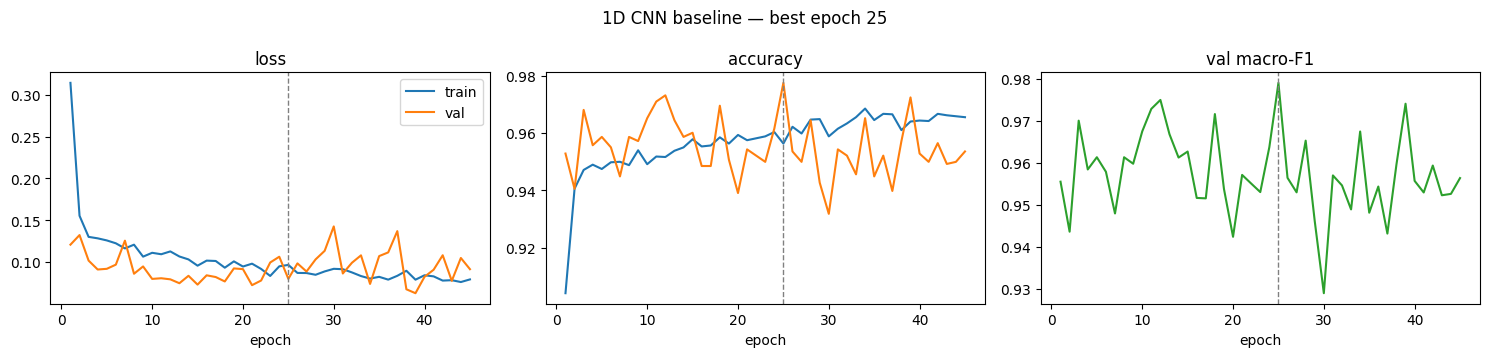

In [7]:
import matplotlib.pyplot as plt
RESULT_DIR = os.path.join(hc.RESULTS_DIR, MODEL_NAME, RUN_TAG); os.makedirs(RESULT_DIR, exist_ok=True)
ep = [h["epoch"] for h in history]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].plot(ep, [h["train_loss"] for h in history], label="train"); ax[0].plot(ep, [h["val_loss"] for h in history], label="val"); ax[0].set_title("loss")
ax[1].plot(ep, [h["train_acc"] for h in history], label="train"); ax[1].plot(ep, [h["val_acc"] for h in history], label="val"); ax[1].set_title("accuracy")
ax[2].plot(ep, [h["val_macro_f1"] for h in history], color="C2"); ax[2].set_title("val macro-F1")
for a in ax:
    a.axvline(best_epoch, ls="--", c="grey", lw=1); a.set_xlabel("epoch")
ax[0].legend(); fig.suptitle(f"1D CNN baseline — best epoch {best_epoch}"); plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "learning_curves.png"), dpi=130); plt.show()

## 5 · Export runnable model files
The deployable model takes **raw** sensor windows `(N, 128, 9)` and returns class probabilities: clipping and normalization (from the shared training statistics) are baked into the graph, so no preprocessing code is needed to use it.

In [8]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="torch")       # jit deprecation notices
warnings.filterwarnings("ignore", category=DeprecationWarning, message=".*TorchScript-based ONNX.*")

norm = hc.SEQ_NORM
class DeployModel(nn.Module):
    """raw (N,128,9) -> clip -> z-score -> 1D CNN -> softmax probabilities (N,6)"""
    def __init__(self, net):
        super().__init__()
        self.net = net
        for k in ("clip_lo", "clip_hi", "mean", "std"):
            self.register_buffer(k, torch.tensor(norm[k], dtype=torch.float32))
    def forward(self, x):
        x = torch.maximum(torch.minimum(x, self.clip_hi), self.clip_lo)
        return torch.softmax(self.net((x - self.mean) / self.std), dim=-1)

model_cpu = copy.deepcopy(model).cpu().eval()
deploy = DeployModel(model_cpu).eval()
raw_test = data["X_test"] * np.array(norm["std"], np.float32) + np.array(norm["mean"], np.float32)
example = torch.from_numpy(raw_test[:2])
ref = deploy(example).detach().numpy()

ARTIFACTS = {}
p = os.path.join(MODEL_DIR, "cnn_state_dict.pt"); torch.save(model_cpu.state_dict(), p); ARTIFACTS["state_dict"] = p
cfg = {"model": "HARCNN1D", "receptive_field_steps": rf, "hyperparameters": HP, "input": {"shape": ["N", int(SEQ_LEN), int(N_CH)], "units": "raw UCI HAR inertial signals",
       "channel_order": hc.SIGNALS}, "output": {"type": "probabilities", "classes": hc.CLASSES},
       "normalization": norm, "dataset_version": hc.DATASET_VERSION, "best_epoch": best_epoch}
p = os.path.join(MODEL_DIR, "model_config.json"); json.dump(cfg, open(p, "w"), indent=2); ARTIFACTS["config"] = p

# TorchScript: one self-contained file, loadable with torch.jit.load — no class definition needed
try:
    ts = torch.jit.trace(deploy, example, check_trace=False)
    p = os.path.join(MODEL_DIR, "cnn_deploy.torchscript.pt"); ts.save(p)
    err = np.abs(torch.jit.load(p)(example).detach().numpy() - ref).max()
    ARTIFACTS["torchscript"] = p; print(f"TorchScript saved  (max |diff| vs PyTorch = {err:.2e})")
except Exception as e:
    print("TorchScript export skipped:", repr(e)[:200])

# ONNX: framework-independent, runs with onnxruntime on any device
try:
    p = os.path.join(MODEL_DIR, "cnn_deploy.onnx")
    kw = dict(input_names=["raw_window"], output_names=["probabilities"], opset_version=17,
              dynamic_axes={"raw_window": {0: "batch"}, "probabilities": {0: "batch"}})
    try:
        torch.onnx.export(deploy, (example,), p, dynamo=False, **kw)
    except TypeError:
        torch.onnx.export(deploy, (example,), p, **kw)
    import onnxruntime as ort
    sess = ort.InferenceSession(p, providers=["CPUExecutionProvider"])
    err = np.abs(sess.run(None, {"raw_window": raw_test[:2]})[0] - ref).max()
    ARTIFACTS["onnx"] = p; print(f"ONNX saved         (max |diff| vs PyTorch = {err:.2e})")
except Exception as e:
    print("ONNX export skipped:", repr(e)[:300])

TorchScript saved  (max |diff| vs PyTorch = 0.00e+00)
ONNX saved         (max |diff| vs PyTorch = 5.53e-10)


### Stand-alone prediction script
`predict.py` runs the exported model on new data with nothing but PyTorch (or onnxruntime) installed.

In [9]:
%%writefile "{MODEL_DIR}/predict.py"
"""Run the exported HAR 1D CNN on raw smartphone sensor windows.

  python predict.py --uci-dir "path/to/UCI HAR Dataset/test"   # reads Inertial Signals (+ y_test.txt if present)
  python predict.py --npy windows.npy                          # raw windows, shape (N, 128, 9)
  add --onnx to use onnxruntime instead of PyTorch
Channel order: body_acc_x/y/z, body_gyro_x/y/z, total_acc_x/y/z (see model_config.json).
"""
import argparse, json, os, sys, time
import numpy as np

HERE = os.path.dirname(os.path.abspath(__file__))
CFG = json.load(open(os.path.join(HERE, "model_config.json")))
CLASSES = CFG["output"]["classes"]; SIGNALS = CFG["input"]["channel_order"]


def load_uci_split(split_dir):
    split = os.path.basename(os.path.normpath(split_dir))
    X = np.stack([np.loadtxt(os.path.join(split_dir, "Inertial Signals", f"{s}_{split}.txt")) for s in SIGNALS], -1)
    y_path = os.path.join(split_dir, f"y_{split}.txt")
    y = np.loadtxt(y_path, dtype=int) - 1 if os.path.exists(y_path) else None
    return X.astype(np.float32), y


def predict(X, use_onnx=False):
    if use_onnx:
        import onnxruntime as ort
        sess = ort.InferenceSession(os.path.join(HERE, "cnn_deploy.onnx"), providers=["CPUExecutionProvider"])
        return np.concatenate([sess.run(None, {"raw_window": X[i:i + 512]})[0] for i in range(0, len(X), 512)])
    import torch
    m = torch.jit.load(os.path.join(HERE, "cnn_deploy.torchscript.pt"), map_location="cpu").eval()
    with torch.no_grad():
        return np.concatenate([m(torch.from_numpy(X[i:i + 512])).numpy() for i in range(0, len(X), 512)])


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    g = ap.add_mutually_exclusive_group(required=True)
    g.add_argument("--uci-dir"); g.add_argument("--npy")
    ap.add_argument("--onnx", action="store_true"); ap.add_argument("--out", help="optional CSV of predictions")
    a = ap.parse_args()
    X, y = load_uci_split(a.uci_dir) if a.uci_dir else (np.load(a.npy).astype(np.float32), None)
    assert X.ndim == 3 and X.shape[1:] == (128, 9), f"expected (N,128,9), got {X.shape}"
    t0 = time.time(); P = predict(X, a.onnx); dt = time.time() - t0
    pred = P.argmax(1)
    print(f"{len(X)} windows in {dt:.2f}s ({'onnx' if a.onnx else 'torchscript'})")
    for i, c in enumerate(CLASSES):
        print(f"  {c:20s} {int((pred == i).sum()):5d}")
    if y is not None:
        print(f"accuracy vs labels: {(pred == y).mean():.4f}")
    if a.out:
        import csv
        with open(a.out, "w", newline="") as f:
            w = csv.writer(f); w.writerow(["window", "predicted"] + [f"p_{c}" for c in CLASSES])
            for i, (k, p) in enumerate(zip(pred, P)):
                w.writerow([i, CLASSES[k]] + [f"{v:.5f}" for v in p])
        print("saved", a.out)

Writing /content/drive/MyDrive/HAR/models/cnn/baseline/predict.py


In [10]:
ARTIFACTS["predict_script"] = os.path.join(MODEL_DIR, "predict.py")
hits = [h for h in glob.glob(os.path.join(PROJECT_DIR, "dataset", "**", "Inertial Signals"), recursive=True) if h.rstrip("/").endswith("test/Inertial Signals")]
if hits and "torchscript" in ARTIFACTS:
    test_dir = os.path.dirname(hits[0])
    print("Running predict.py on the original raw test files (end-to-end check):")
    r = subprocess.run([sys.executable, ARTIFACTS["predict_script"], "--uci-dir", test_dir], capture_output=True, text=True)
    print(r.stdout or r.stderr)

Running predict.py on the original raw test files (end-to-end check):
2947 windows in 2.60s (torchscript)
  WALKING                515
  WALKING_UPSTAIRS       479
  WALKING_DOWNSTAIRS     417
  SITTING                503
  STANDING               496
  LAYING                 537
accuracy vs labels: 0.9396



## 6 · Final evaluation and efficiency

In [11]:
from torch.utils.flop_counter import FlopCounterMode
p_train = predict_proba(model, data["X_train"])
p_val   = predict_proba(model, data["X_val"])
p_test  = predict_proba(model, data["X_test"])          # first and only use of the test set

with FlopCounterMode(display=False) as fc:
    model_cpu(torch.from_numpy(data["X_test"][:1]))
flops = int(fc.get_total_flops())

x1_cpu = torch.from_numpy(data["X_test"][:1])
with torch.inference_mode():
    cpu = hc.measure_latency(lambda x: model_cpu(x).numpy(), x1_cpu)
gpu = {}
if USE_AMP:
    model.eval()
    xb1, xb256 = x1_cpu.to(DEVICE), torch.from_numpy(data["X_test"][:256]).to(DEVICE)
    with torch.inference_mode():
        gpu = hc.measure_latency(lambda x: model(x).cpu(), xb1, xb256)

EFFICIENCY = dict(
    params_total=n_params, params_trainable=n_train,
    model_size_mb=round(os.path.getsize(ARTIFACTS["state_dict"]) / 2**20, 3),
    flops_per_window=flops, flops_tool="torch.utils.flop_counter (2 x MACs)",
    latency_ms_cpu_b1=round(cpu["latency_ms_b1_mean"], 3), latency_ms_cpu_b1_p95=round(cpu["latency_ms_b1_p95"], 3),
    cpu_threads=torch.get_num_threads(),
    latency_ms_gpu_b1=round(gpu["latency_ms_b1_mean"], 3) if gpu else None,
    throughput_gpu_wps=round(gpu["throughput_wps"], 1) if gpu else None,
    peak_gpu_mem_mb=TRAINING["peak_gpu_mem_mb"])
EFFICIENCY

{'params_total': 197190,
 'params_trainable': 197190,
 'model_size_mb': 0.766,
 'flops_per_window': 24856064,
 'flops_tool': 'torch.utils.flop_counter (2 x MACs)',
 'latency_ms_cpu_b1': 1.264,
 'latency_ms_cpu_b1_p95': 1.52,
 'cpu_threads': 1,
 'latency_ms_gpu_b1': 1.053,
 'throughput_gpu_wps': 61135.5,
 'peak_gpu_mem_mb': 57.1}

## 7 · Record results (shared format)

Saved cnn__baseline__20261002-110759
  details -> /content/drive/MyDrive/HAR/results/cnn/baseline
  table   -> /content/drive/MyDrive/HAR/results/comparison_table.csv

TEST  accuracy 0.9396 | macro-F1 0.9406 | kappa 0.9274 | sit/stand confusion 0.129 | worst subject acc 0.785
VAL   macro-F1 0.9790 | TRAIN macro-F1 0.9680
                    precision    recall  f1-score   support

           WALKING     0.9631    1.0000    0.9812       496
  WALKING_UPSTAIRS     0.9478    0.9639    0.9558       471
WALKING_DOWNSTAIRS     0.9976    0.9905    0.9940       420
           SITTING     0.8310    0.8513    0.8410       491
          STANDING     0.9032    0.8421    0.8716       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9396      2947
         macro avg     0.9405    0.9413    0.9406      2947
      weighted avg     0.9395    0.9396    0.9393      2947



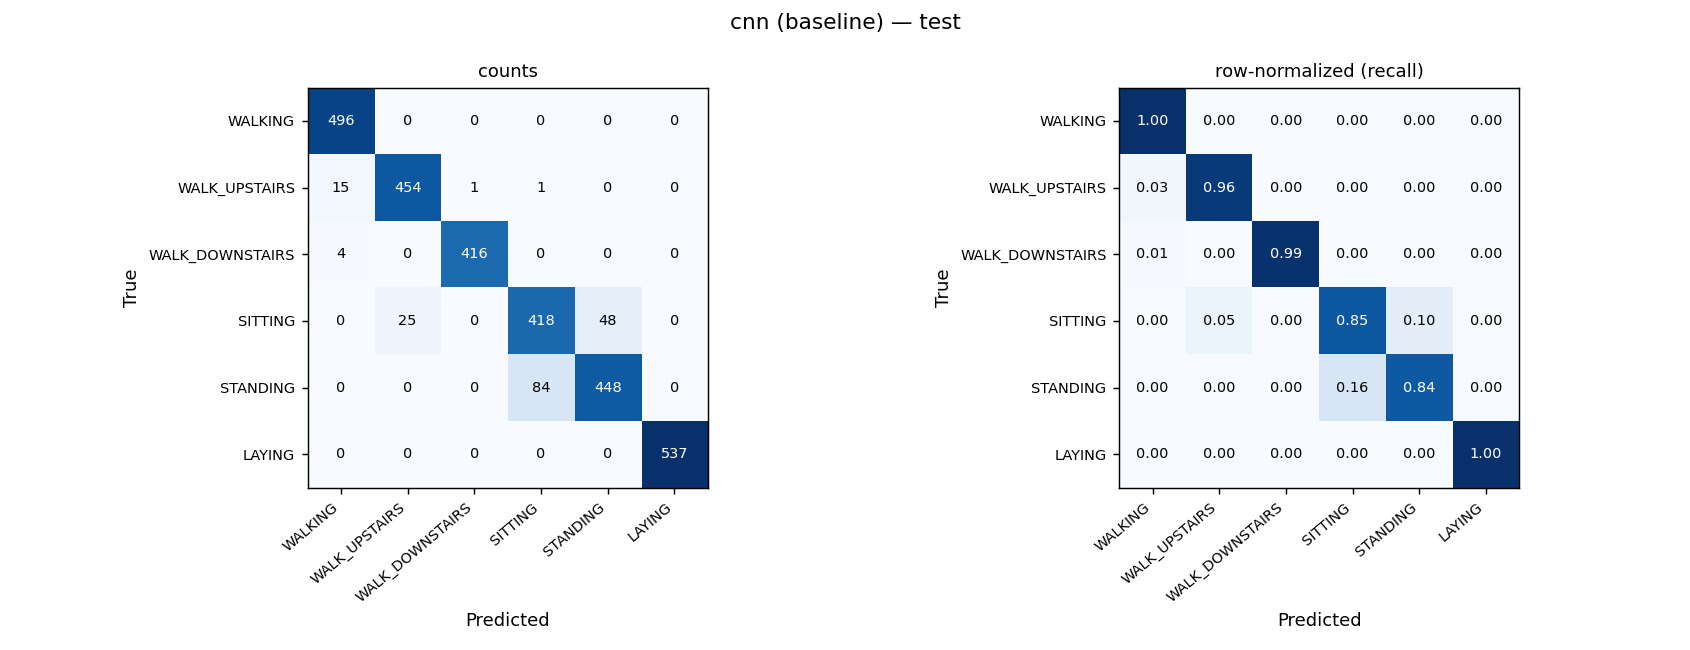

In [12]:
record = hc.save_results(
    model_name=MODEL_NAME, family=FAMILY, owner=OWNER, input_representation="raw_9ch_128", run_tag=RUN_TAG,
    y_test=data["y_test"], p_test=p_test, s_test=data["s_test"],
    y_val=data["y_val"], p_val=p_val, y_train=data["y_train"], p_train=p_train,
    efficiency=EFFICIENCY, training=TRAINING, hyperparameters=HP, history=history,
    framework=f"PyTorch {torch.__version__}", artifacts=ARTIFACTS, seed=SEED,
    notes="Unoptimized baseline, parallel to the Transformer run: 150 epochs max, patience 20, no augmentation, no class weights, constant LR; FLOPs via torch flop_counter.")

t = record["test"]
print(f"\nTEST  accuracy {t['accuracy']:.4f} | macro-F1 {t['macro_f1']:.4f} | kappa {t['cohen_kappa']:.4f} | "
      f"sit/stand confusion {t['sit_stand_confusion_rate']:.3f} | worst subject acc {t['subject_acc_min']:.3f}")
print(f"VAL   macro-F1 {record['val']['macro_f1']:.4f} | TRAIN macro-F1 {record['train']['macro_f1']:.4f}")
print(open(os.path.join(RESULT_DIR, "classification_report.txt")).read())
from IPython.display import Image, display
display(Image(os.path.join(RESULT_DIR, "confusion_matrix.png")))

In [13]:
import pandas as pd
table = pd.read_csv(os.path.join(hc.RESULTS_DIR, "comparison_table.csv"))
cols = ["model_name", "run_tag", "owner", "test_accuracy", "test_macro_f1", "test_cohen_kappa",
        "sit_stand_confusion_rate", "walking_variants_confusion_rate", "subject_acc_min",
        "params_total", "model_size_mb", "latency_ms_cpu_b1", "train_time_s"]
table[cols].round(4)

,model_name,run_tag,owner,test_accuracy,test_macro_f1,test_cohen_kappa,sit_stand_confusion_rate,walking_variants_confusion_rate,subject_acc_min,params_total,model_size_mb,latency_ms_cpu_b1,train_time_s
0,transformer,baseline,K V Ananth Karantha,0.9284,0.9268,0.9140,0.086,0.0822,0.7211,76422,0.303,3.006,76.90
1,cnn,baseline,Akshaj Vinod Chandak,0.9396,0.9406,0.9274,0.129,0.0144,0.7847,197190,0.766,1.264,39.64


## Outputs
| Where | What |
|---|---|
| `DL Proj/models/cnn/baseline/` | `cnn_deploy.torchscript.pt`, `cnn_deploy.onnx` (raw input → probabilities), `cnn_state_dict.pt`, `model_config.json`, `predict.py` |
| `DL Proj/results/cnn/baseline/` | `metrics.json` (everything), `history.csv`, `classification_report.txt`, `confusion_matrix.png`, `learning_curves.png` |
| `DL Proj/results/comparison_table.csv` | one row per run, shared by all four models |

Use the exported model anywhere:
```bash
python "DL Proj/models/cnn/baseline/predict.py" --uci-dir "DL Proj/dataset/UCI HAR Dataset/test"
```
Re-running this notebook adds a new row (with a new `run_id`) rather than overwriting the old one. For the tuned version, change `RUN_TAG = "tuned"` and the `HP` values.

Commit to GitHub: this notebook → `notebooks/`, `results/cnn/` and `models/cnn/` → your branch → pull request.